**Student Lifestyle and Academic Performance Analysis**

This project explores how lifestyle factors such as
study hours, sleep duration, and social media usage affect students' academic performance and mental health.

The dataset contains information on student habits including study time, sleep, physical activity, stress level, and CGPA. The goal is to explore relationships between these variables using visualization and statistical modelling.


In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [14]:
df = pd.read_csv("/content/student_lifestyle_100k.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114.0,5.0,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142.0,2.0,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137.0,3.0,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130.0,3.0,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4.0,6.0,False


In [15]:
df.shape

(20539, 11)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20539 entries, 0 to 20538
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          20539 non-null  int64  
 1   Age                 20539 non-null  int64  
 2   Gender              20539 non-null  object 
 3   Department          20539 non-null  object 
 4   CGPA                20538 non-null  float64
 5   Sleep_Duration      20538 non-null  float64
 6   Study_Hours         20538 non-null  float64
 7   Social_Media_Hours  20538 non-null  float64
 8   Physical_Activity   20538 non-null  float64
 9   Stress_Level        20538 non-null  float64
 10  Depression          20538 non-null  object 
dtypes: float64(6), int64(2), object(3)
memory usage: 1.7+ MB


In [17]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,20539.000000,20539.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000
mean,11270.000000,21.014217,2.902706,6.987068,4.518887,3.509748,74.518697,4.137404
std,5929.242925,2.006148,0.533852,1.500963,1.971813,1.488135,43.261576,1.418927
min,1001.000000,18.000000,1.590000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,6135.500000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,11270.000000,21.000000,2.910000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,16404.500000,23.000000,3.357500,8.000000,5.900000,4.500000,112.000000,5.000000
max,21539.000000,24.000000,4.000000,12.000000,12.300000,9.800000,149.000000,10.000000


In [18]:
df.corr(numeric_only=True)

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
Student_ID,1.000000,-0.008406,-0.008894,-0.001501,-0.000898,-0.009030,-0.003154,-0.001605
Age,-0.008406,1.000000,0.001844,0.001934,-0.000493,-0.007469,-0.006848,0.003981
CGPA,-0.008894,0.001844,1.000000,0.013124,0.099148,-0.097222,0.010509,-0.025821
Sleep_Duration,-0.001501,0.001934,0.013124,1.000000,0.009904,-0.000664,0.006385,-0.284583
Study_Hours,-0.000898,-0.000493,0.099148,0.009904,1.000000,0.006256,0.000452,-0.000010
Social_Media_Hours,-0.009030,-0.007469,-0.097222,-0.000664,0.006256,1.000000,0.005647,0.004713
Physical_Activity,-0.003154,-0.006848,0.010509,0.006385,0.000452,0.005647,1.000000,-0.295620
Stress_Level,-0.001605,0.003981,-0.025821,-0.284583,-0.000010,0.004713,-0.295620,1.000000


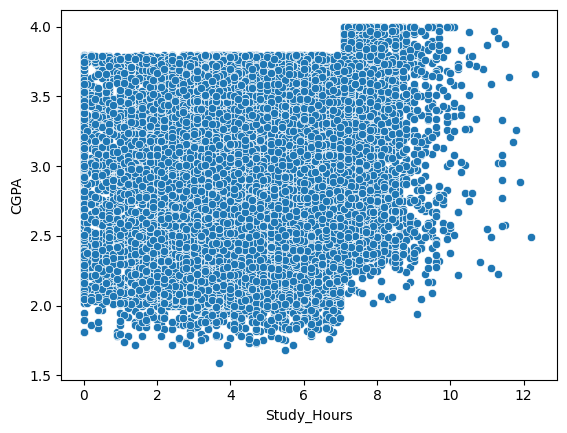

In [19]:
sns.scatterplot(x="Study_Hours", y="CGPA", data=df)
plt.show()

In [20]:
df = df.dropna()

In [21]:
X = df[["Study_Hours", "Sleep_Duration", "Social_Media_Hours", "Stress_Level", "Physical_Activity"]]
y = df["CGPA"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   CGPA   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     84.19
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           7.41e-88
Time:                        08:44:10   Log-Likelihood:                -16043.
No. Observations:               20538   AIC:                         3.210e+04
Df Residuals:                   20532   BIC:                         3.215e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.9208      0

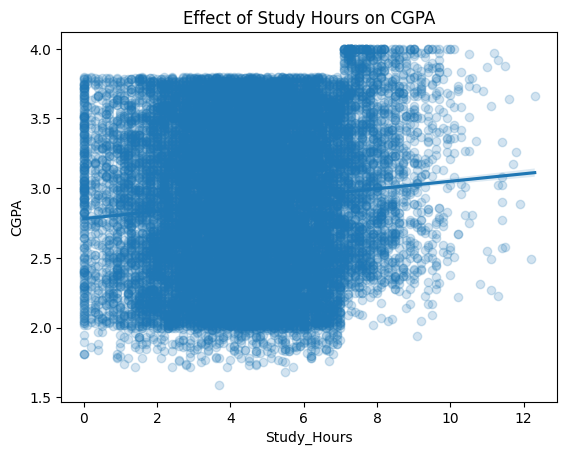

In [22]:
sns.regplot(x="Study_Hours", y="CGPA", data=df, scatter_kws={"alpha":0.2})
plt.title("Effect of Study Hours on CGPA")
plt.show()

## Conclusion

This project analyzed how lifestyle factors influence students' academic performance (CGPA) using a dataset of over 20,000 observations. The analysis included exploratory data analysis, visualizations, and an OLS regression model.



*   The regression results suggest that study habits and lifestyle behaviors have measurable but relatively small effects on academic performance. Study hours show a positive and statistically significant relationship with CGPA, indicating that students who spend more time studying tend to achieve slightly higher academic performance. In contrast, social media usage has a negative and significant relationship with CGPA, suggesting that higher time spent on social media may be associated with lower academic outcomes.

*   Stress levels also show a small but statistically significant negative effect on CGPA, implying that higher stress may slightly reduce academic performance. However, sleep duration and physical activity were not statistically significant predictors in the model.


*   The overall explanatory power of the model is relatively low (R² ≈ 0.02), which indicates that while lifestyle factors do play a role, most variation in CGPA is explained by other factors not included in this dataset, such as prior academic ability, study quality, or external circumstances.

*   Overall, the results suggest that balanced study habits and limited social media usage may contribute to improved academic performance, although lifestyle factors alone cannot fully explain differences in student outcomes.






